<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/SFDS/Final_Dragon_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dragon Flame Regression Project**

* Beberto Baloyi (1042653)
* Kwanda Mazibuko (1077167)
* Simamkele Xipu (2927823)


<div style="text-align: center;">
   <img src="https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/dragon_project.png"  width="800">
</div>

## **SECTION 1: Import Libraries, Load Dataset and Data Cleaning**

In [ ]:
# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (LinearRegression, Ridge, Lasso)

from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error)

from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

### **Load Dataset**

In [ ]:
# LOAD DATASET

df = pd.read_csv("https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/dragon_data.csv")


df.head()

,SPC,AGE,MASS,WSP,HID,SPD,FHO
0,Wyvern,16,1304,4.0,4.83,4800,611
1,Dragon,2726,3693174,52.0,4.82,114400,1960
2,Dragon,377,154201,19.4,4.61,42680,1123
3,Hydra,169,40146,13.0,2.65,7800,706
4,Dragon,1571,1549315,39.6,1.49,87120,1441


### **Data Cleaning**

In [ ]:
# DATA CLEANING


# Check shape
print("Dataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Check data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (500, 7)

Missing Values:

SPC     0
AGE     0
MASS    0
WSP     0
HID     0
SPD     0
FHO     0
dtype: int64

Data Types:

SPC      object
AGE       int64
MASS      int64
WSP     float64
HID     float64
SPD       int64
FHO       int64
dtype: object


In [ ]:
# FIX DATA QUALITY ISSUES

# Fix typo in species name

df['SPC'] = df['SPC'].replace('Wyvernn', 'Wyvern')

# Remove impossible negative ages

df = df[df['AGE'] > 0]

# Reset index

df.reset_index(drop=True, inplace=True)

print("\nCleaned Dataset Shape:", df.shape)


Cleaned Dataset Shape: (499, 7)


The dataset contained two important quality issues:

* A typo in the species column ("Wyvernn"), which would create incorrect categories.
* Negative age values, which are biologically impossible.

Cleaning these issues improves model reliability and prevents incorrect statistical relationships.

## **SECTION 2: Exploratory Data Analysis (EDA)**

In [ ]:
# SUMMARY STATISTICS
df.describe()

,AGE,MASS,WSP,HID,SPD,FHO
count,499.000000,4.990000e+02,499.000000,499.000000,499.000000,499.000000
mean,463.362725,3.094201e+05,18.191984,3.002505,24152.865731,893.478958
std,642.506471,7.524684e+05,11.514057,1.166180,26595.341629,350.412031
min,1.000000,1.700000e+01,1.000000,1.010000,600.000000,100.000000
25%,107.500000,1.923750e+04,10.400000,1.920000,7650.000000,664.000000
50%,242.000000,7.940400e+04,15.600000,2.940000,13860.000000,869.000000
75%,586.000000,2.829250e+05,24.200000,4.040000,29580.000000,1107.000000
max,5407.000000,9.729833e+06,73.600000,5.000000,161920.000000,2358.000000


* AGE, MASS, and SPD show very large variation because their standard deviations are high compared to their means.
* MASS is highly positively skewed because the mean is much larger than the median and the maximum value is extremely high.
* SPD also appears skewed because a few dragons have extremely high flight speeds compared to most observations.
* FHO is more evenly distributed because the mean and median are relatively close together.
* Potential outliers are observed in AGE, MASS, and SPD because the maximum values are far larger than the upper quartiles.

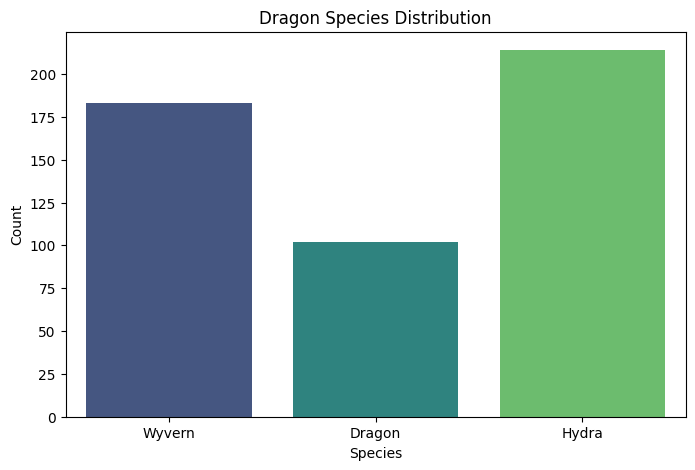

In [ ]:
# DRAGON SPECIES DISTRIBUTION

plt.figure(figsize = (8,5))

sns.countplot(
    data = df,
    x = 'SPC',
    palette = 'viridis'
)

plt.title('Dragon Species Distribution')
plt.xlabel('Species')
plt.ylabel('Count')

plt.show()

Overall, the Hydra spcies has the highest number of spcies followed by Wyvern and Dragon has the lease number of species

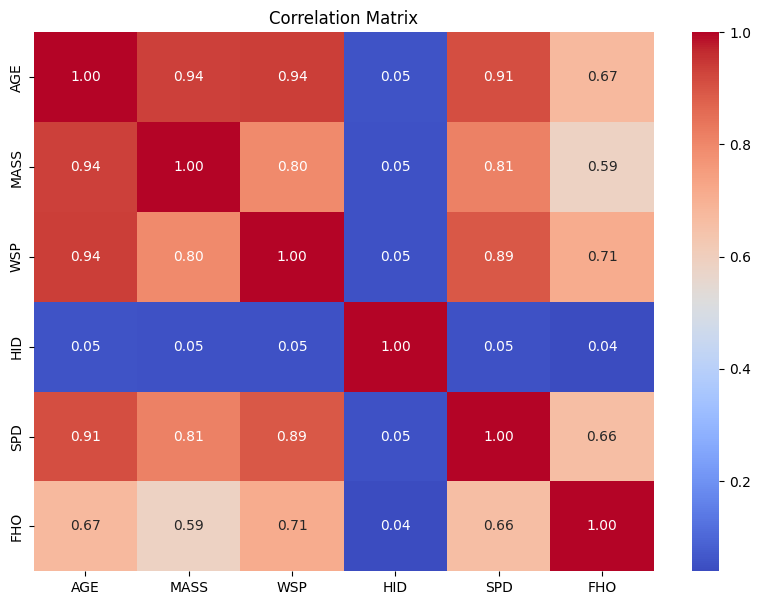

In [ ]:
# CORRELATION HEATMAP

numerical_cols = ['AGE', 'MASS', 'WSP', 'HID', 'SPD', 'FHO']

plt.figure(figsize = (10,7))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)

plt.title('Correlation Matrix')
plt.savefig('Correlation_Matrix.png')
plt.show()

* WSP has the strongest correlation with FHO (0.71), making it the best predictor.
* AGE (0.67) and SPD (0.66) also show strong positive relationships with FHO.
* MASS has a moderate positive correlation with FHO (0.59).
* HID has almost no relationship with FHO (0.04).
* Strong correlations between AGE, MASS, WSP, and SPD suggest multicollinearity may exist.

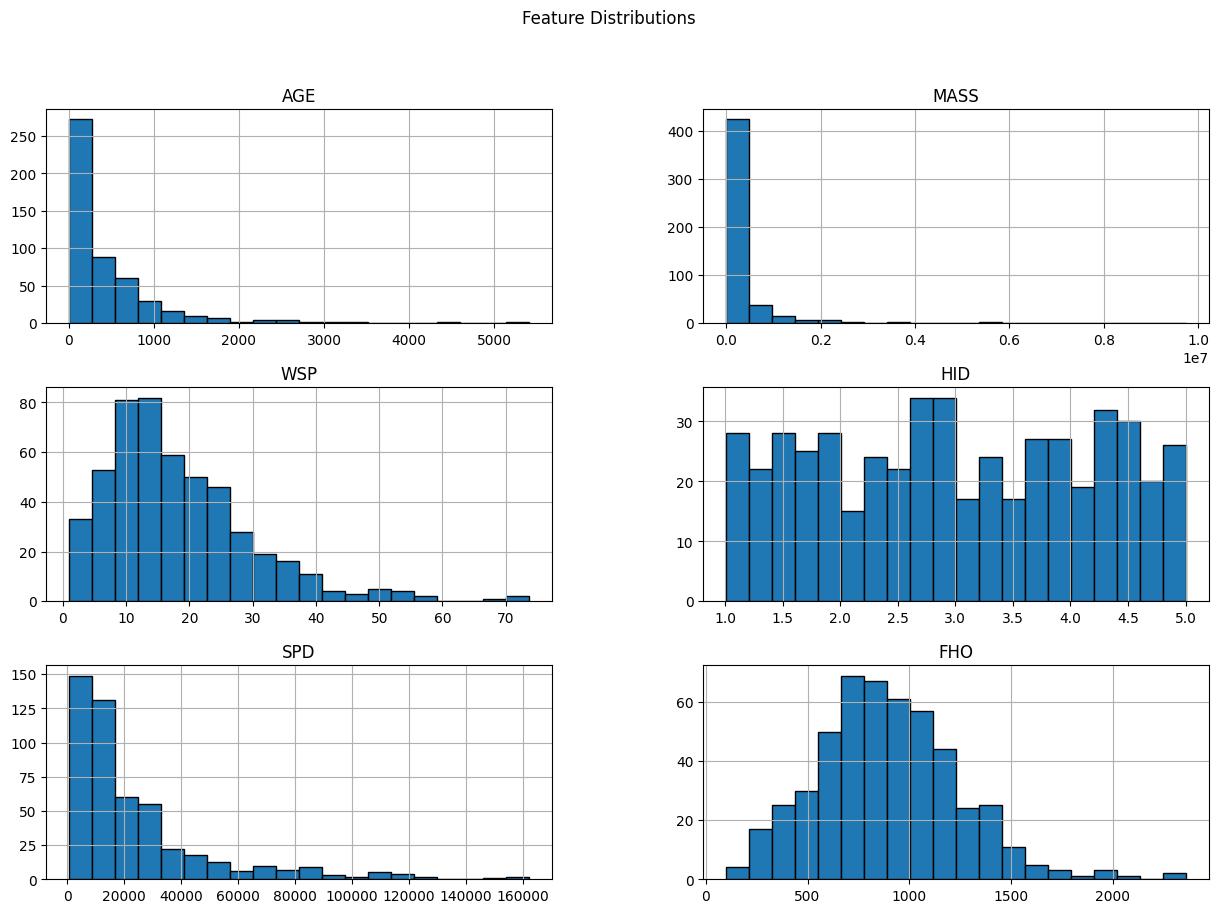

In [ ]:
# HISTOGRAMS

df.hist(
    figsize = (15,10),
    bins = 20,
    edgecolor = 'black'
)

plt.suptitle('Feature Distributions')
plt.savefig('Histograms.png')
plt.show()

* AGE, MASS, and SPD are highly positively skewed with long right tails.
* MASS and SPD contain extreme values, indicating possible outliers.
* WSP shows moderate positive skewness but appears more evenly distributed.
* HID is relatively uniformly distributed across its range.
* FHO appears closer to a normal distribution compared to the other variables.

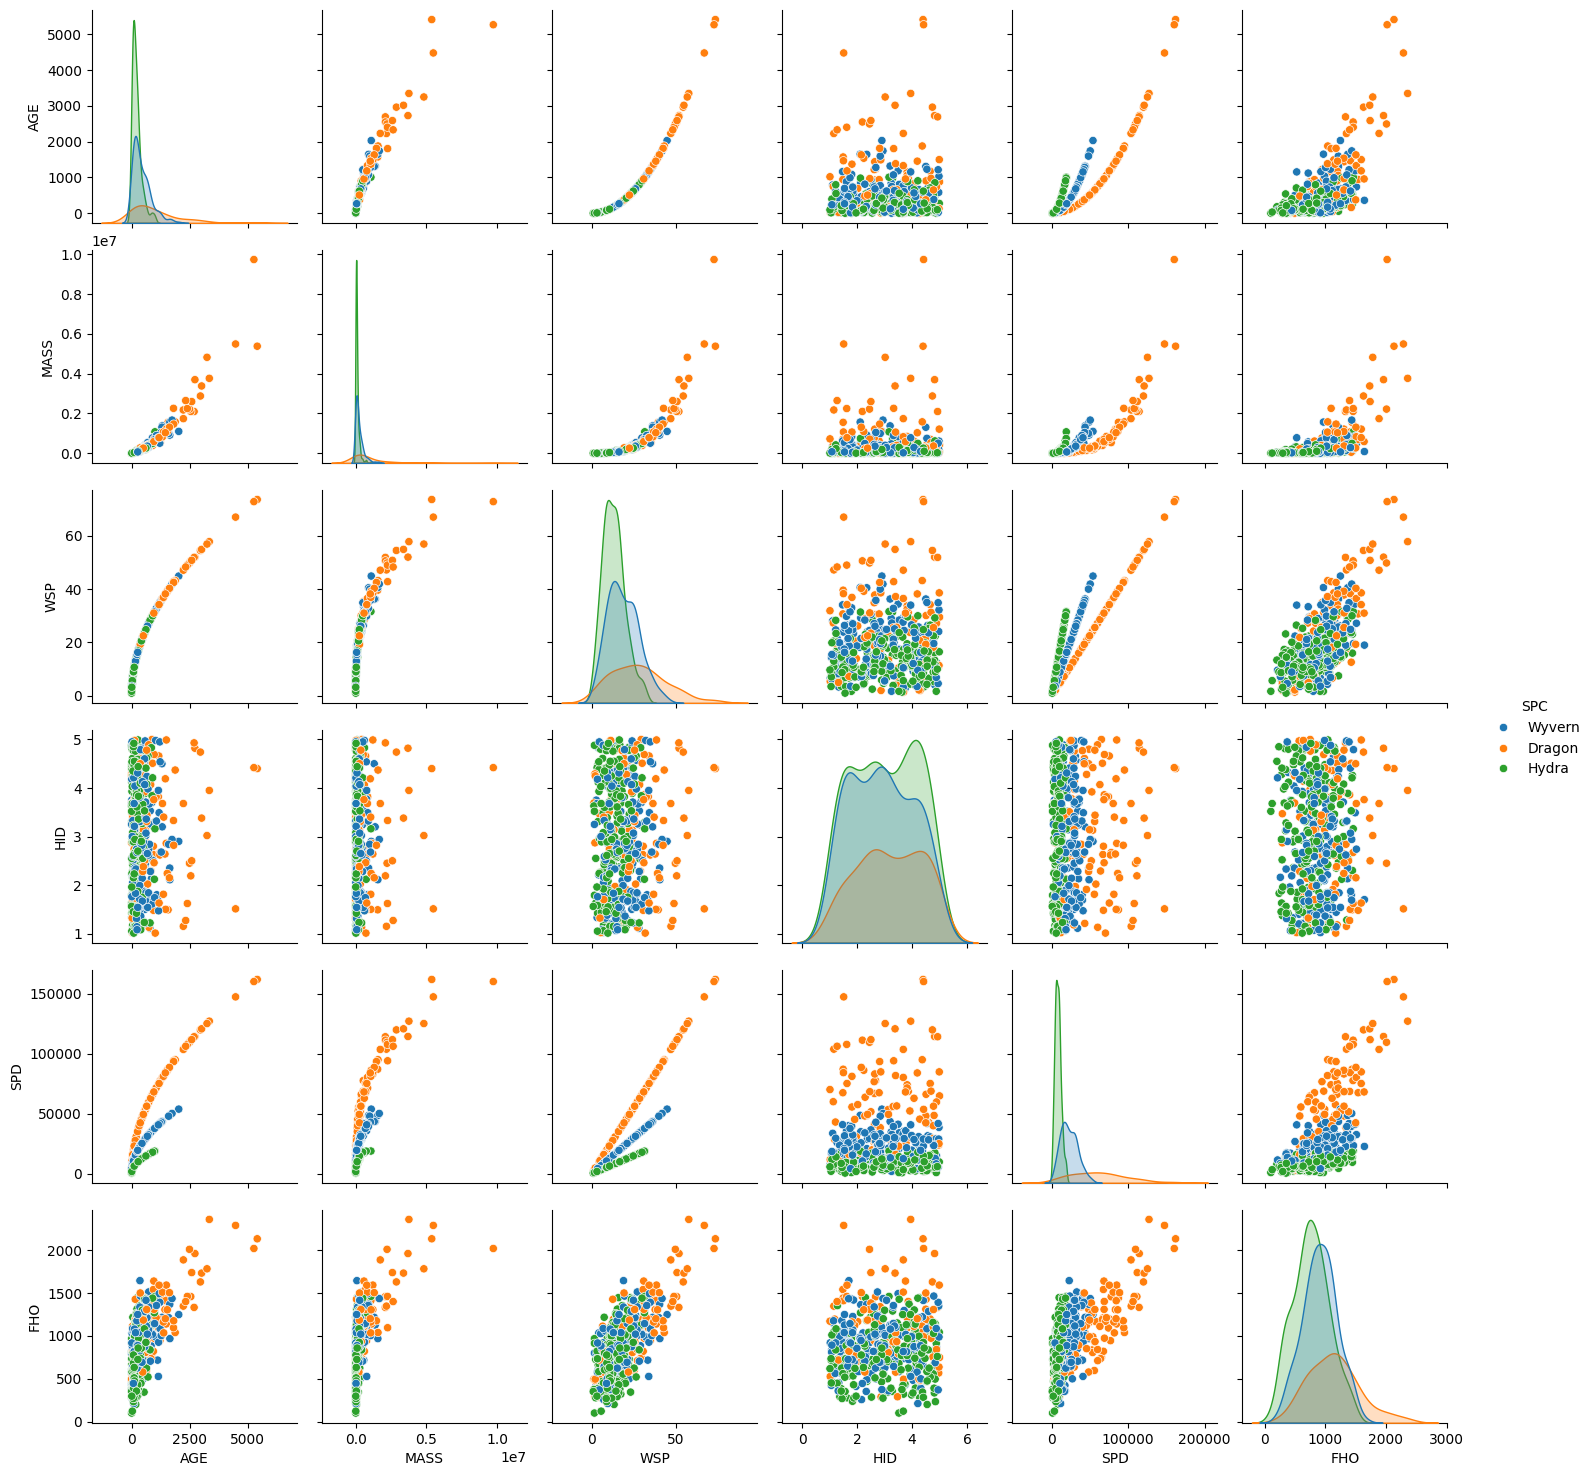

In [ ]:
# PAIRPLOT

sns.pairplot(
    df,
    hue = 'SPC'
)
plt.savefig('Pairplot.png')
plt.show()

* Strong positive relationships exist between FHO and variables such as WSP, AGE, MASS, and SPD.
* HID shows weak relationships with most variables, suggesting limited predictive power.
* Some relationships appear non-linear, especially for MASS and SPD.
* Distinct species clusters are visible, indicating species differences influence dragon characteristics.
* The clear upward trends suggest regression models should perform reasonably well for predicting FHO.
* Dragons appear to have the highest values for AGE, MASS, SPD, and FHO compared to Wyverns and Hydras.                                                                                  

## **SECTION 3: Train-Test Split**

In [ ]:

# DEFINE FEATURES AND TARGET


X = df.drop('FHO', axis=1)
y = df['FHO']


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (399, 6)
Testing Size: (100, 6)


The dataset is split into training and testing sets to evaluate how well the models generalise to unseen data.

* Training data is used for learning.
* Test data is used for evaluation.

An 80/20 split is commonly used in machine learning.

## **SECTION 4: Single Variable Regression**

### **Single Variable Regression Function**

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# SINGLE VARIABLE REGRESSION FUNCTION

def evaluate_single_variable(feature_name):

    # Define X and y
    X_single = df[[feature_name]]
    y_single = df['FHO']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_single,
        y_single,
        test_size = 0.2,
        random_state = 42
    )

    # Handle categorical variable
    if feature_name == 'SPC':

        preprocessor = ColumnTransformer(
            transformers = [
                ('cat', OneHotEncoder(drop = 'first'), ['SPC'])
            ]
        )

        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LinearRegression())
        ])

    else:

        model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # R-squared
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Print results
    print(f'\nFeature: {feature_name}')
    print(f'Train R-squared  : {train_r2:.4f}')
    print(f'Test R-squared  : {test_r2:.4f}')
    print(f'Train RMSE: {train_rmse:.2f}')
    print(f'Test RMSE : {test_rmse:.2f}')

    return {
        'Feature': feature_name,
        'Train R-squared': train_r2,
        'Test R-squared': test_r2,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Model': model
    }

We created a reusable function to avoid duplicating code across regression models. The function handles both numerical and categorical variables appropriately.

### **WSP Regression**


Feature: WSP
Train R-squared  : 0.5009
Test R-squared  : 0.5249
Train RMSE: 248.10
Test RMSE : 237.17


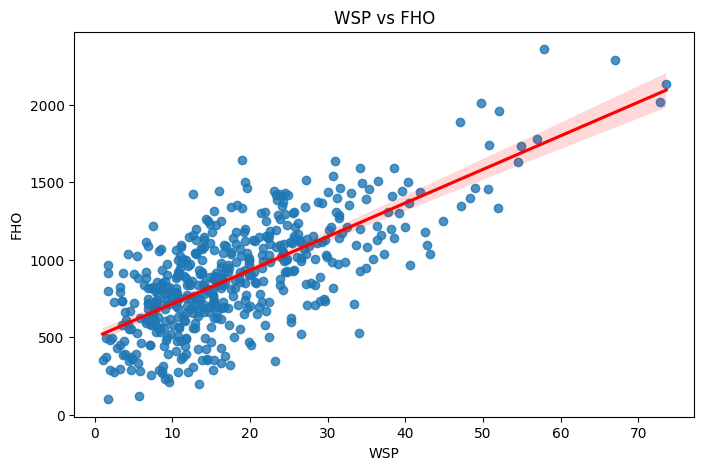

In [ ]:
# WSP REGRESSION

model_wsp = evaluate_single_variable('WSP')

# Plot
plt.figure(figsize = (8,5))

sns.regplot(
    data = df,
    x = 'WSP',
    y = 'FHO',
    line_kws = {'color':'red'}
)

plt.title('WSP vs FHO')
plt.savefig('WSP_Regression.png')
plt.show()

MASS Regression


Feature: MASS
Train R-squared  : 0.3425
Test R-squared  : 0.3253
Train RMSE: 284.75
Test RMSE : 282.62


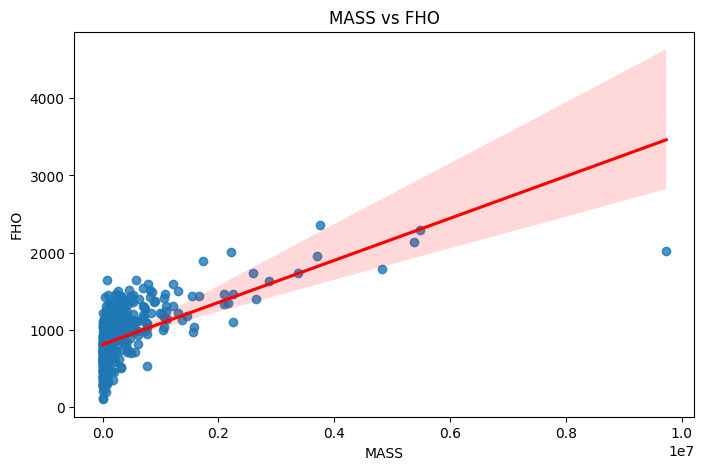

In [ ]:
# MASS REGRESSION

model_mass = evaluate_single_variable('MASS')

# Plot
plt.figure(figsize = (8,5))

sns.regplot(
    data = df,
    x = 'MASS',
    y = 'FHO',
    line_kws = {'color':'red'}
)

plt.title('MASS vs FHO')
plt.savefig('MASS_Regression.png')
plt.show()

AGE Regression


Feature: AGE
Train R-squared  : 0.4494
Test R-squared  : 0.4570
Train RMSE: 260.57
Test RMSE : 253.55


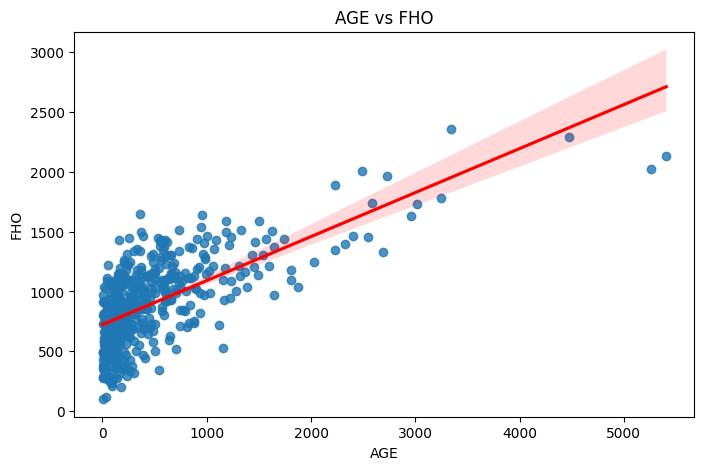

In [ ]:
# AGE REGRESSION

model_age = evaluate_single_variable('AGE')

# Plot
plt.figure(figsize=(8,5))

sns.regplot(
    data = df,
    x = 'AGE',
    y = 'FHO',
    line_kws = {'color':'red'}
)

plt.title('AGE vs FHO')
plt.savefig('AGE_Regression.png')
plt.show()

SPC Regregression


Feature: SPC
Train R-squared  : 0.1756
Test R-squared  : 0.0702
Train RMSE: 318.84
Test RMSE : 331.78


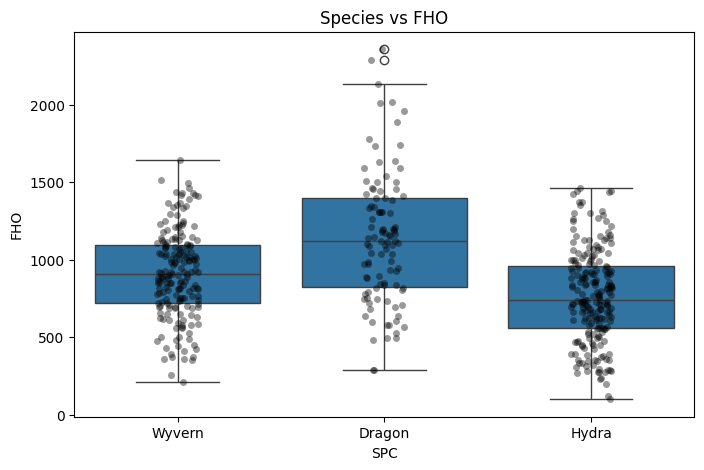

In [ ]:
# SPC Regregression
model_spc = evaluate_single_variable('SPC')

#Plot
plt.figure(figsize = (8,5))

sns.boxplot(
    data = df,
    x = 'SPC',
    y = 'FHO'
)

sns.stripplot(
    data = df,
    x = 'SPC',
    y = 'FHO',
    color = 'black',
    alpha = 0.4
)

plt.title('Species vs FHO')
plt.savefig('SPC_Boxplot.png')
plt.show()

From the findings in the single-variable regression models, it is evident that wingspan (WSP) is the best single predictor of Flame Heat Output (FHO). Wingspan shows the highest R-squared score of 0.525, indicating that it explains about 52.5 per cent of the variance in FHO. This suggests that predicting flame heat from wingspan is reasonably accurate, owing to the lower RMSE of 237.17.

The second most important predictor was age (AGE), with an R-squared score of 0.457. This clearly indicates that age influences flame production; hence, there are differences in flames created by young and old dragons.

For MASS, the R-squared score was 0.325. The relationship between mass and heat produced seems weak, since the RMSE was higher than for AGE and WSP.
The species (SPC) factor proved to be the least predictive, yielding an R-squared of just 0.070 on the test dataset. This implies that, on its own, species information has poor predictive value for Flame Heat Output. Different species may even be adequately represented by physical features such as wingspan, mass, and age.

Overall, Wingspan is the most informative variable among those considered, followed by age and mass. Species, on its own, has poor predictive power. Similar R-squared values for the training and testing data in all cases imply that there is no problem with model over-fitting.


## **SECTION 6: Multiple Variable Regression**

In [ ]:
#Model development with the different combination of variables

results = []

models = {
    'Model 1': ['WSP', 'MASS'],
    'Model 2': ['WSP', 'MASS', 'AGE'],
    'Model 3': ['WSP', 'MASS', 'AGE', 'SPD', 'HID'],
    'Model 4': ['WSP', 'MASS', 'AGE', 'SPD', 'HID', 'SPC']
}

# X and Y variables definition

for model_name, features in models.items():

    X = df[features]
    y = df['FHO']

    categorical_features = X.select_dtypes(include = ['object']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers = [
            ('cat', OneHotEncoder(drop = 'first'), categorical_features)
        ],
        remainder = 'passthrough'
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        'Model': model_name,
        'Features': ', '.join(features),
        'Train_R-Squared': round(r2_score(y_train, train_pred), 4),
        'Test_R-Squared': round(r2_score(y_test, test_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, test_pred)), 2)
    })

results_df = pd.DataFrame(results)
print("                      Multiple Variable Models")
print(results_df)

                      Multiple Variable Models
     Model                       Features  Train_R-Squared  Test_R-Squared  \
0  Model 1                      WSP, MASS           0.5019          0.5253   
1  Model 2                 WSP, MASS, AGE           0.5022          0.5263   
2  Model 3       WSP, MASS, AGE, SPD, HID           0.5058          0.5236   
3  Model 4  WSP, MASS, AGE, SPD, HID, SPC           0.5082          0.5228   

     RMSE  
0  237.07  
1  236.81  
2  237.48  
3  237.68  


In [ ]:
# Function for each multiple variable plots

def regression_plots(model, X_test, y_test, model_name):

    # Predictions
    y_pred = model.predict(X_test)

    # Residuals
    residuals = y_test - y_pred

    # Actual vs Predicted
    plt.figure(figsize = (8,5))

    plt.scatter(y_test, y_pred)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )

    plt.xlabel('Actual FHO')
    plt.ylabel('Predicted FHO')
    plt.title(f'{model_name}: Actual vs Predicted')

    plt.savefig(f'{model_name}_Actual_vs_Predicted.png')
    plt.show()

    # Residual Plot
    plt.figure(figsize = (8,5))

    plt.scatter(y_pred, residuals)

    plt.axhline(
        y = 0,
        color = 'red',
        linestyle = '--'
    )

    plt.xlabel('Predicted FHO')
    plt.ylabel('Residuals')
    plt.title(f'{model_name}: Residual Plot')

    plt.savefig(f'{model_name}_Residuals.png')
    plt.show()

**Model 1': ['WSP', 'MASS']**

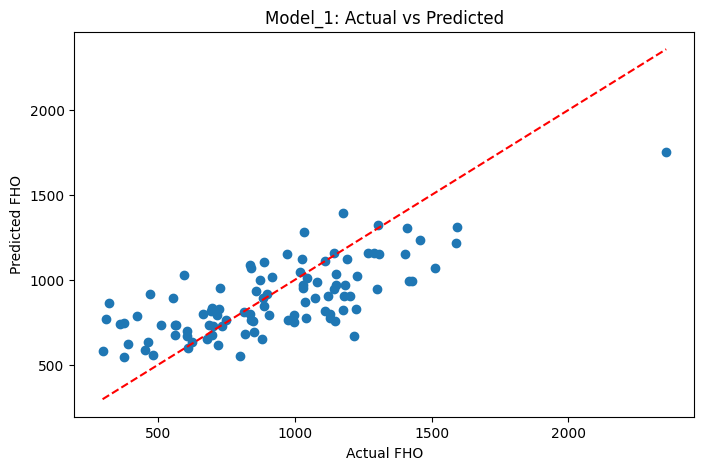

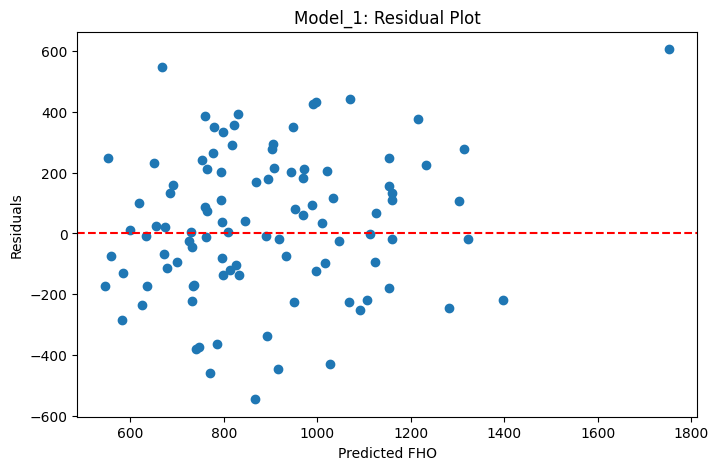

In [ ]:
features = ['WSP', 'MASS']

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

model1 = LinearRegression()

model1.fit(X_train, y_train)

regression_plots(
    model1,
    X_test,
    y_test,
    'Model_1'
)

**Model 2: ['WSP', 'MASS', 'AGE']**

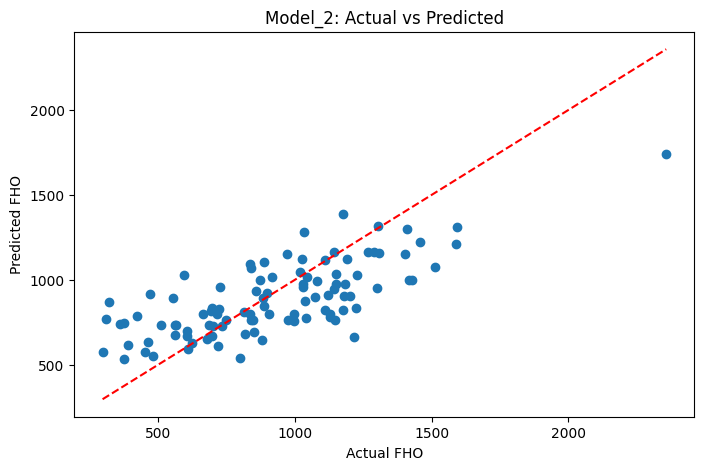

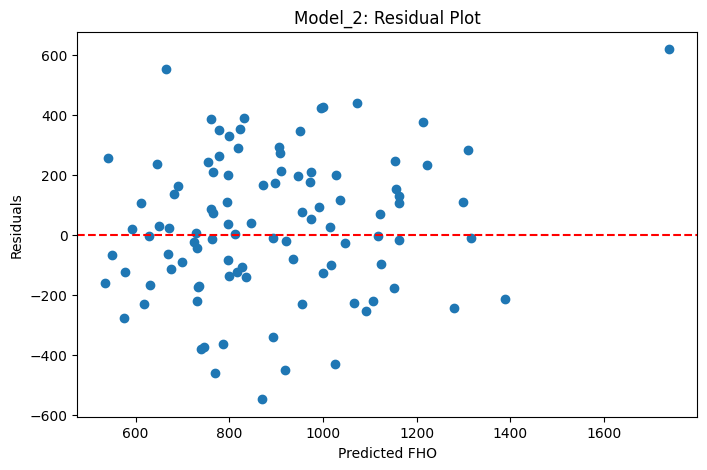

In [ ]:
features = ['WSP', 'MASS', 'AGE']

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

model2 = LinearRegression()

model2.fit(X_train, y_train)

regression_plots(
    model2,
    X_test,
    y_test,
    'Model_2'
)

**Model 3: ['WSP', 'MASS', 'AGE', 'SPD', 'HID']**

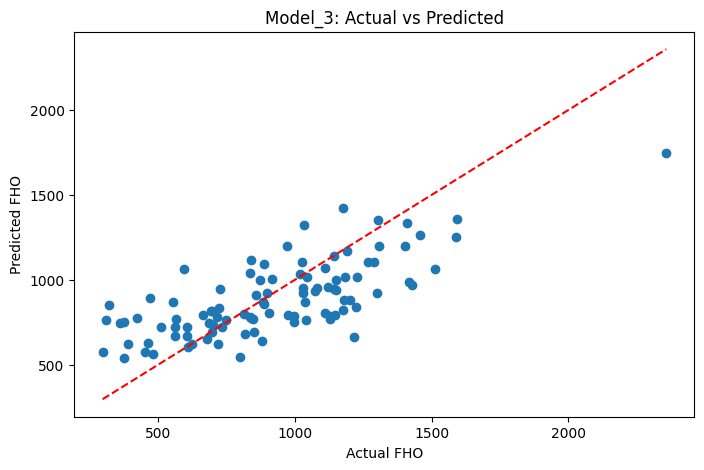

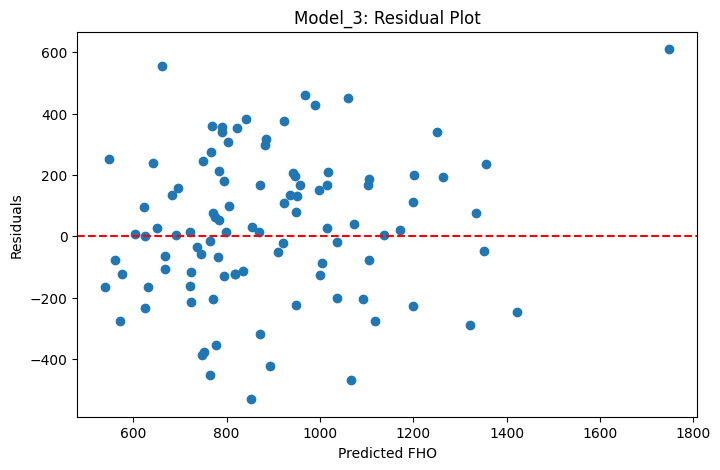

In [ ]:
features = ['WSP', 'MASS', 'AGE', 'SPD', 'HID']

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

model3 = LinearRegression()

model3.fit(X_train, y_train)

regression_plots(
    model3,
    X_test,
    y_test,
    'Model_3'
)

**Model 4: ['WSP', 'MASS', 'AGE', 'SPD', 'HID', 'SPC']**

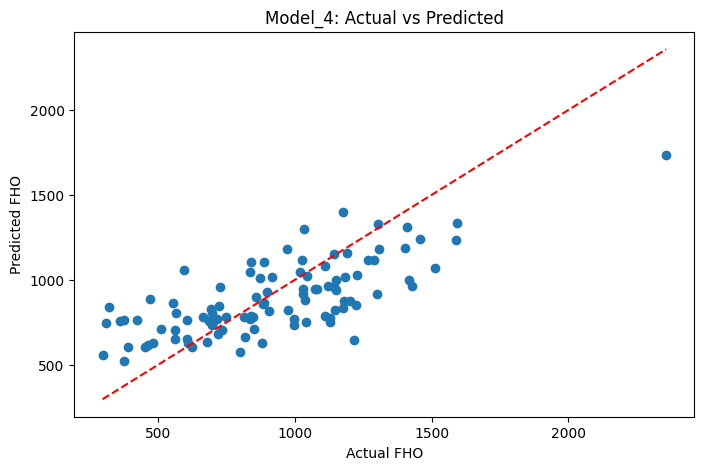

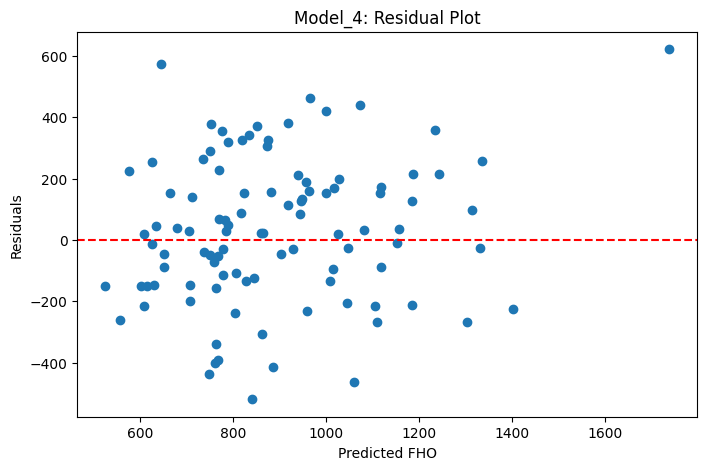

In [ ]:
features = ['WSP', 'MASS', 'AGE', 'SPD', 'HID', 'SPC']

X = df[features]
y = df['FHO']

categorical_features = ['SPC']

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop = 'first'), categorical_features)
    ],
    remainder = 'passthrough'
)

model4 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

model4.fit(X_train, y_train)

regression_plots(
    model4,
    X_test,
    y_test,
    'Model_4'
)

Different multiple linear regression models were created using various combinations of predictor variables to identify the set that could predict FHO well.

In Model 1, WSP and MASS were used as input variables, as both are physical parameters related to the size of the dragons and their energy capacity. Using these variables, an R-Squared of 0.5019 was obtained during training, while 0.5253 was attained during testing, implying that the two variables can explain about 52.5% of FHO variance.

Model 2 used three variables – WSP, AGE, and MASS. Since AGE reflects experience, we included this parameter, as older dragons are likely to have more advanced fire organs and can better control their flame heat output than younger ones. By adding AGE to the input variables, the model produced the highest accuracy, with a training R-Squared of 0.5022, a test R-Squared of 0.5263, and the smallest RMSE of 236.81.

Model 3 additionally considered sustained flight speed (SPD) and hide thickness (HID). These features were intended to represent physiological characteristics associated with energy consumption and temperature regulation. However, adding these parameters slightly reduced test performance, yielding a test R-Squared of 0.5236 and an RMSE of 237.48. Consequently, SPD and HID do not add much to predictive ability.

Model 4 contained all possible variables, including the dragon species (SPC). While this model demonstrated the highest R-Squared on the training set (0.5082), the test R-Squared fell to 0.5228, and the RMSE increased to 237.68. Thus, the dragon species parameter is not informative enough for predicting Flame Heat Output.

In conclusion, the second model demonstrated the best performance and produced the best results. It showed the highest test R-Squared and the lowest prediction error. In addition, the similarity of R-Squared between the training and test sets across all cases indicates that none of the developed models experienced serious overfitting.


## **SECTION 6: Model Comparison**

Comparison of the four models, the best was selected based on training R-Squared, test R-Squared and RMSE. The models slightly outperformed the first model, which contained only WSP and MASS, as adding AGE increased the training and test R-Squared and decreased the RMSE. Model 2 produced the highest test R-Squared at 0.5263 and the lowest RMSE (236.81).

Introducing additional variables did not improve the models' accuracy. For instance, although Model 3 included SPD and HID, it had a lower test R-Squared at 0.5236 than Model 2. Likewise, despite introducing SPC as well as other variables, Model 4 achieved a test R-Squared of only 0.5228. The comparison makes it clear that the inclusion of extra variables did not contribute much to the models.

There does not seem to be an overfitting problem. The test R-Squared for each model is slightly lower than the training R-Squared, indicating that the models generalise well enough to provide good predictions for unseen data.

Based on the results presented above, it can be concluded that Model 2 should be used, as it yields higher predictive accuracy with three predictor variables. Although Models 3 and 4 are more complex, the remaining variables don't play a major role and therefore do not improve predictive accuracy when compared with Model 2.


## **SECTION 7: Model Comparison (Interpretability)**

In [ ]:
from sklearn.linear_model import LinearRegression

# Model 1
model1 = LinearRegression()
model1.fit(df[['WSP', 'MASS']], df['FHO'])

print("\nMODEL 1")
print(pd.DataFrame({
    'Feature': ['WSP', 'MASS'],
    'Coefficient': model1.coef_
}))

# Model 2
model2 = LinearRegression()
model2.fit(df[['WSP', 'MASS', 'AGE']], df['FHO'])

print("\nMODEL 2")
print(pd.DataFrame({
    'Feature': ['WSP', 'MASS', 'AGE'],
    'Coefficient': model2.coef_
}))

# Model 3
model3 = LinearRegression()
model3.fit(df[['WSP', 'MASS', 'AGE', 'SPD', 'HID']], df['FHO'])

print("\nMODEL 3")
print(pd.DataFrame({
    'Feature': ['WSP', 'MASS', 'AGE', 'SPD', 'HID'],
    'Coefficient': model3.coef_
}))

# Model 4
X = pd.get_dummies(
    df[['WSP', 'MASS', 'AGE', 'SPD', 'HID', 'SPC']],
    drop_first=True
)

model4 = LinearRegression()
model4.fit(X, df['FHO'])

print("\nMODEL 4")
print(pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model4.coef_
}))


MODEL 1
  Feature  Coefficient
0     WSP    20.409015
1    MASS     0.000024

MODEL 2
  Feature  Coefficient
0     WSP    22.696212
1    MASS     0.000059
2     AGE    -0.078009

MODEL 3
  Feature  Coefficient
0     WSP    21.693156
1    MASS     0.000066
2     AGE    -0.133275
3     SPD     0.001689
4     HID     0.347432

MODEL 4
      Feature  Coefficient
0         WSP    22.710741
1        MASS     0.000067
2         AGE    -0.082308
3         SPD    -0.000794
4         HID    -0.141706
5   SPC_Hydra   -92.930242
6  SPC_Wyvern   -54.325239


### Interpretability of the Preferred Model (Model 2)

Model 2 was chosen because it had the highest test R-Squared (0.5263) and the lowest RMSE (236.81). This model is based on the following variables – wingspan (WSP), mass (MASS) and age (AGE) – as predictors of Flame Heat Output (FHO).

The coefficient for WSP is large and positive. This means that, if everything else stays the same, a one-metre difference in wingspan increases Flame Heat Output by about 22.7°C. This finding seems biologically justified, as a greater wingspan indicates a larger dragon that produces more energy. Thus, wingspan proves to be the main predictor of flame heat output.

The variable of mass also has a positive correlation with FHO, as the coefficient (0.000059) shows. This means that bigger and heavier dragons produce flames that are much hotter. This result might seem rather small. However, the scale of measurement for this variable is enormous, as the values of mass may range from tens up to millions of tons.

Coefficients for age (-0.078) show that aging dragons tend towards slightly cooler flames, provided that wingspan and mass are constant. Such an outcome may seem unexpected at first sight, since age may imply more developed flame-production abilities. This finding may reveal that ageing influences metabolism, or that ageing dragons still have less intense flames despite experience and size.

In general, most coefficients' signs align with dragon biology. Older dragons seem to have less impact on fire intensity than younger dragons, while larger dragons produce higher temperatures. It can be presumed that bigger dragons produce more intense flames because they have greater capabilities.

Wingspan seems to be the best predictor of Flame Heat Output, since it has the highest coefficient and performs best in simple regression models. The second-best predictor in terms of influence seems to be Mass, although its comparison with Wingspan is less direct, due to the scale difference. Lastly, Age influences Flame Heat Output the least out of all three variables considered.

An important feature of the selected model is the negative Age coefficient. In essence, it means that while old dragons have more experience, their flames tend to become less efficient due to physical ageing effects.


A notable finding is the negative age coefficient. This may suggest that physical ageing reduces flame efficiency, even though older dragons have greater experience. This result highlights the importance of considering biological trade-offs when interpreting the model.


## **SECTION 8: Model Evaluation**

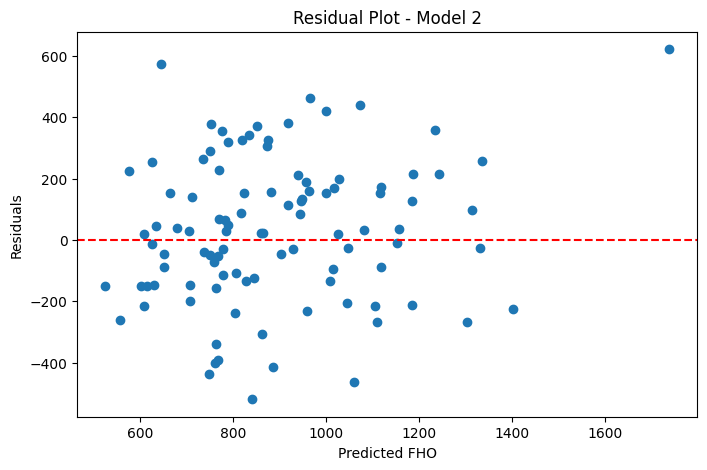

In [ ]:
residuals = y_test - test_pred

plt.figure(figsize = (8,5))

plt.scatter(test_pred, residuals)

plt.axhline(y = 0, color = 'red', linestyle = '--')

plt.xlabel('Predicted FHO')
plt.ylabel('Residuals')
plt.title('Residual Plot - Model 2')

plt.show()

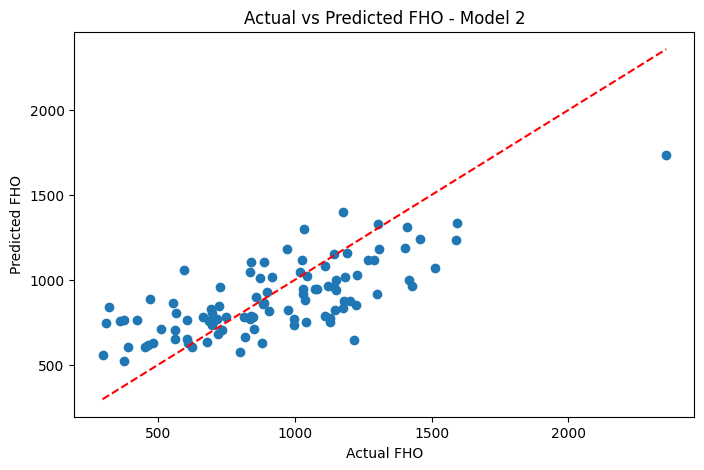

In [ ]:
plt.figure(figsize = (8,5))

plt.scatter(y_test, test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual FHO')
plt.ylabel('Predicted FHO')
plt.title('Actual vs Predicted FHO - Model 2')

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

X = df[['WSP', 'MASS', 'AGE']]
y = df['FHO']

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv = 5,
    scoring = 'r2'
)

print("CV Scores:", scores)
print("Mean CV R-Squared:", scores.mean())
print("Std CV R-Squared:", scores.std())

CV Scores: [0.44861515 0.53074621 0.42207432 0.53362937 0.41311822]
Mean CV R-Squared: 0.4696366550239139
Std CV R-Squared: 0.05239820251399415


### Model Evaluation

The performance of the regression models was assessed using residual analysis, prediction error measures, test set results, and cross-validation. The residual analysis showed that the residuals were distributed almost randomly around zero, implying that the assumptions of linear regression had been largely met and that no pattern remained unaccounted for.

Based on the error measures, Model 2 emerged as having the best overall performance, with the highest Test R-Squared of 0.5263 and the lowest RMSE of 236.81. Model 2 thus gives the most accurate predictions for Flame Heat Output among the four models. Although Models 3 and 4 added more explanatory variables compared to Model 2, they did not reduce prediction error.

The similarity in R-Squared values between the training and test sets across all four models denotes excellent generalisation performance. Indeed, the R-Squared values in the test sets were better than those in the training sets, indicating that the models do not suffer from overfitting. This indicates that the discovered relationships are likely to hold for dragons beyond those used during training and validation.

Furthermore, 5-fold cross-validation was used to assess the stability of the selected model. The R-Squared values for cross-validation in each fold were 0.449, 0.531, 0.422, 0.534, and 0.413, yielding a mean R-Squared of 0.470 and a low standard deviation of 0.052. The small standard deviation indicates a high level of stability in the model with regard to predicting the variable of interest. Although the mean cross-validation R-Squared is lower than the test R-Squared calculated from a single split of the dataset, the model exhibits moderate generalisability.

Therefore, the results of the assessment show that Model 2 offers a sufficient combination of predictive accuracy, model simplicity, and generalisability. Although the model can predict around half of the variation in Flame Heat Output, further research should include additional independent variables.


## **SECTION 9: FEATURE ENGINEERING**

### Feature Engineering Model
To assess the potential to improve the model, additional engineered features were derived from the original variables. Specifically, log_MASS and log_AGE were taken as the logarithms of the original variables, while sqrt_AGE was taken as the square root of AGE. These new features allowed for the presence of skewness and possible non-linearity in relation to Flame Heat Output (FHO). Additionally, interactions were created (WSP_MASS, WSP_AGE, and MASS_AGE) to assess whether interactions between dragon characteristics could affect flame output. A total of three feature-engineered models were created, based on different combinations of the newly engineered features, in comparison with the basic one (WSP, MASS, AGE).

In [ ]:
# Create engineered features

df_fe = df.copy()

# Log transformations
df_fe['log_MASS'] = np.log(df_fe['MASS'])
df_fe['log_AGE'] = np.log(df_fe['AGE'])

# Square-root transformation
df_fe['sqrt_AGE'] = np.sqrt(df_fe['AGE'])

# Interaction terms
df_fe['WSP_MASS'] = df_fe['WSP'] * df_fe['MASS']
df_fe['WSP_AGE'] = df_fe['WSP'] * df_fe['AGE']
df_fe['MASS_AGE'] = df_fe['MASS'] * df_fe['AGE']


# Function to evaluate engineered models

def evaluate_engineered_model(df, features):

    X = df[features]
    y = df['FHO']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    return {
        'Features': ', '.join(features),
        'Train_R-Squared': round(train_r2,4),
        'Test_R-Squared': round(test_r2,4),
        'RMSE': round(rmse,2)
    }

# BASELINE MODEL (MODEL 2)


baseline = evaluate_engineered_model(
    df_fe,
    ['WSP', 'MASS', 'AGE']
)

# FEATURE ENGINEERED MODEL 1

fe_model1 = evaluate_engineered_model(
    df_fe,
    [
        'WSP',
        'log_MASS',
        'log_AGE',
        'WSP_MASS'
    ]
)

# FEATURE ENGINEERED MODEL 2


fe_model2 = evaluate_engineered_model(
    df_fe,
    [
        'WSP',
        'log_MASS',
        'sqrt_AGE',
        'WSP_AGE'
    ]
)

# FEATURE ENGINEERED MODEL 3

fe_model3 = evaluate_engineered_model(
    df_fe,
    [
        'WSP',
        'log_MASS',
        'log_AGE',
        'WSP_MASS',
        'WSP_AGE'
    ]
)



# COMPARISON TABLE

feature_engineering_results = pd.DataFrame([
    baseline,
    fe_model1,
    fe_model2,
    fe_model3
])

feature_engineering_results.index = [
    'Baseline Model',
    'FE Model 1',
    'FE Model 2',
    'FE Model 3'
]

print(feature_engineering_results)

                                                 Features  Train_R-Squared  \
Baseline Model                             WSP, MASS, AGE           0.5022   
FE Model 1               WSP, log_MASS, log_AGE, WSP_MASS           0.5110   
FE Model 2               WSP, log_MASS, sqrt_AGE, WSP_AGE           0.5049   
FE Model 3      WSP, log_MASS, log_AGE, WSP_MASS, WSP_AGE           0.5120   

                Test_R-Squared    RMSE  
Baseline Model          0.5263  236.81  
FE Model 1              0.5543  229.70  
FE Model 2              0.5318  235.42  
FE Model 3              0.5567  229.10  


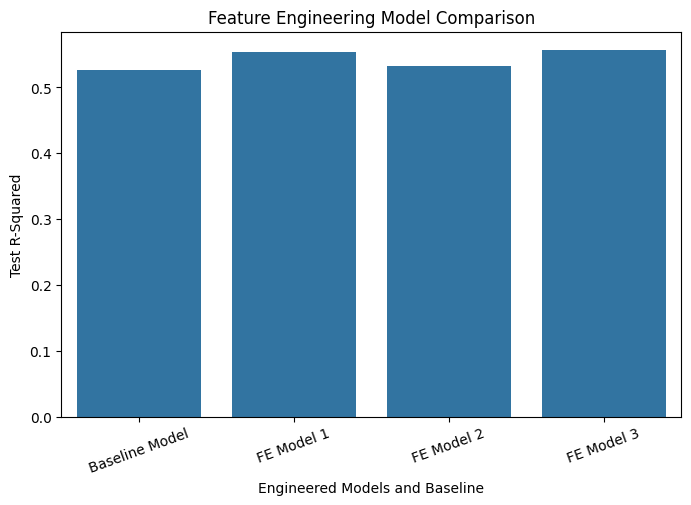

In [ ]:
plt.figure(figsize = (8,5))

sns.barplot(
    x = feature_engineering_results.index,
    y = feature_engineering_results['Test_R-Squared']
)

plt.ylabel('Test R-Squared')
plt.xlabel('Engineered Models and Baseline')
plt.title('Feature Engineering Model Comparison')

plt.xticks(rotation=20)

plt.show()

### Feature Engineering Model Comparison with the Baseline
The results show that the feature engineering models performed better than the benchmark Model 2, confirming that feature engineering and interaction variables were successful at finding more relationships between the dragon attributes and Flame Heat Output (FHO). The test R-Squared and RMSE for both FE Model 1 and FE Model 3 were higher than those of the benchmark model. Of the four models, the best results were obtained by FE Model 3, which achieved a Test R-Squared score of 0.5567 and an RMSE of 229.10, outperforming the Test R-Squared of 0.5263 and RMSE of 236.81 from the baseline model.

This implies that the relationship between a dragon's features and its ability to produce flames is not linear. It appears that logarithmic transformations of variables such as mass and age were used to account for skewness and diminishing returns in these values. Interaction effects were introduced to capture the joint influence of both variables. This can include interactions such as wind speed multiplied by mass and wind speed multiplied by age. Given the superior fit of FE Model 3, we can conclude that flame heat generation depends not only on individual factors but also on their interaction. FE Model 3 should be adopted as our optimal model.

## **SECTION 10: Feature engineering VS Laso and Ridge regularisation**

### Laso and Ridge regularisation
To address issues arising from using more engineered features, Ridge and Lasso Regularisation were implemented. Introducing interaction features can increase model complexity and lead to multicollinearity, as predictors become too correlated. Ridge Regularisation reduces the impact of predictors by shrinking their values towards zero, while Lasso Regularisation sets some predictor coefficients to zero.

The comparison was carried out to determine which approach would yield better results - improving the features (feature engineering) or limiting model complexity (using Ridge or Lasso).


In [ ]:
# Initialise the Laso and Ridge regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def evaluate_model(model, X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = 0.2,
        random_state = 42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        'Train_R-Squared': round(r2_score(y_train, train_pred),4),
        'Test_R-Squared': round(r2_score(y_test, test_pred),4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, test_pred)),2)
    }

In [ ]:
features = [
    'WSP',
    'log_MASS',
    'log_AGE',
    'WSP_MASS',
    'WSP_AGE'
]

X = df_fe[features]
y = df_fe['FHO']

In [ ]:
# Linear from Feature Engineering
linear_results = evaluate_model(
    LinearRegression(),
    X,
    y
)

In [ ]:
# Ridge from Feature Engineering
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha = 1.0))
])

ridge_results = evaluate_model(
    ridge_model,
    X,
    y
)

In [ ]:
#lasso from Feature Engineering
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha = 0.1))
])

lasso_results = evaluate_model(
    lasso_model,
    X,
    y
)

In [ ]:
# COMPARE FEATURE ENGINEERED MODELS WITH MODEL 2
# Baseline Model 2 Results
baseline_results = {
    'Model': 'Model 2 (Baseline)',
    'Train_R-Squared': 0.5022,
    'Test_R-Squared': 0.5263,
    'RMSE': 236.81
}

results = [baseline_results]

# Models to compare
comparison_models = {
    'Linear Regression': LinearRegression(),

    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha = 1.0))
    ]),

    'Lasso Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha = 0.1))
    ])
}

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

# Evaluate models
for model_name, model in comparison_models.items():

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        'Model': model_name,
        'Train_R-Squared': round(r2_score(y_train, train_pred),4),
        'Test_R-Squared': round(r2_score(y_test, test_pred),4),
        'RMSE': round(
            np.sqrt(mean_squared_error(y_test, test_pred)),2
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Train_R-Squared,Test_R-Squared,RMSE
0,Model 2 (Baseline),0.5022,0.5263,236.81
1,Linear Regression,0.5120,0.5567,229.10
2,Ridge Regression,0.5108,0.5478,231.38
3,Lasso Regression,0.5119,0.5550,229.52


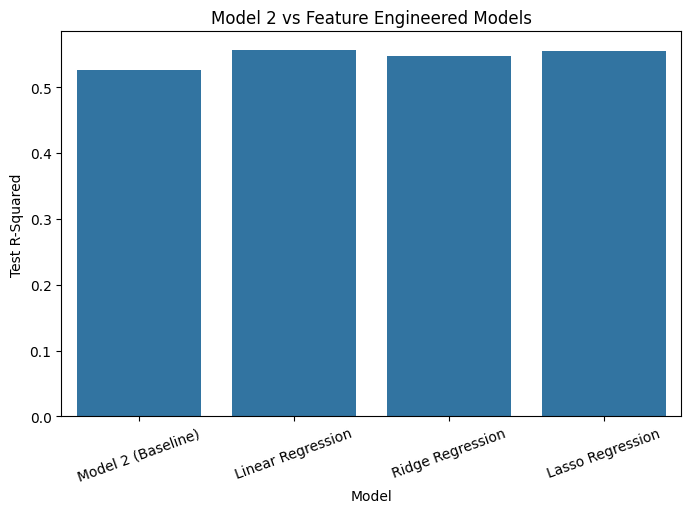

In [ ]:
plt.figure(figsize = (8,5))

sns.barplot(
    data = results_df,
    x = 'Model',
    y = 'Test_R-Squared'
)

plt.title('Model 2 vs Feature Engineered Models')
plt.ylabel('Test R-Squared')

plt.xticks(rotation = 20)

plt.show()

Both feature engineering and regularisation methods were considered to assess whether they could improve predictive accuracy compared with the basic Model 2. Model 2 had a Test R-Squared of 0.5263 and an RMSE of 236.81. After feature engineering, including transformations and interactions, the best-performing regression model was the feature-engineered linear regression model, with a Test R-Squared of 0.5567 and an RMSE of 229.10. This represents a clear improvement in both measures of accuracy.

Both Ridge and Lasso regression models were employed to assess whether regularisation could improve performance by addressing multicollinearity and model complexity. Although the regularised models performed better than the base model, they did not outperform the engineered-feature linear regression model. The performance metrics for Ridge and Lasso regressions were Test R-Squared = 0.5478 and RMSE = 231.38 for Ridge regression, and Test R-Squared = 0.5550 and RMSE = 229.52 for Lasso regression, respectively. These results indicate that the main difference is from feature engineering. Accordingly, the engineered-feature linear regression model is proposed as the final model.

## **Overall Observations**

In conclusion, Feature Engineering was useful in boosting the efficiency of prediction using the regression models, since transformations and interaction variables were applied. Log and square root transformations were employed to capture non-linear relationships and reduce skewness, while interaction variables such as WSP * MASS and WSP * AGE were included to account for interactions among dragon characteristics. Using these features boosted the model's performance, as shown by a comparison between the Test R-Squared at 0.5263 of the baseline model and the Test R-Squared at 0.5567 of the most effective feature-engineered model, as well as a decrease in the RMSE (236.81 to 229.10). This shows that the Flame Heat Output depends not only on individual dragon characteristics but also on their interactions. Thus, Feature Engineering was effective in improving predictive power and helped formulate the final recommendation.

Both lasso and ridge regularisation techniques also performed better than the baseline model, indicating that they helped manage model complexity. Neither was more effective than the most effective feature-engineered linear regression model.
